**Problem Set 1: Question 4**

(a)

In [11]:
import math
from scipy.integrate import quad
from tabulate import tabulate

#define integrand
def integrand(phi):
  return (2/math.pi)*(1/math.sqrt(1-((math.sin(theta/2)) * (math.sin(phi)))**2))

#define limits of integration
a = 0
b = (math.pi)/2

#evaluate integral for different values of theta
angles = [1, 5, 10, 20, 30, 45, 70, 90]
results = []
for angle in angles:
  theta = math.radians(angle)
  result, error = quad(integrand, a, b)
  results.append([angle, result])

headers = ['Angle (degrees)', 'T/T0']
print(tabulate(results, headers = headers, floatfmt = '0.6f'))

  Angle (degrees)      T/T0
-----------------  --------
                1  1.000019
                5  1.000476
               10  1.001907
               20  1.007669
               30  1.017409
               45  1.039973
               70  1.102145
               90  1.180341


(b)

slope = 0.06296146867107583
c = 1/16


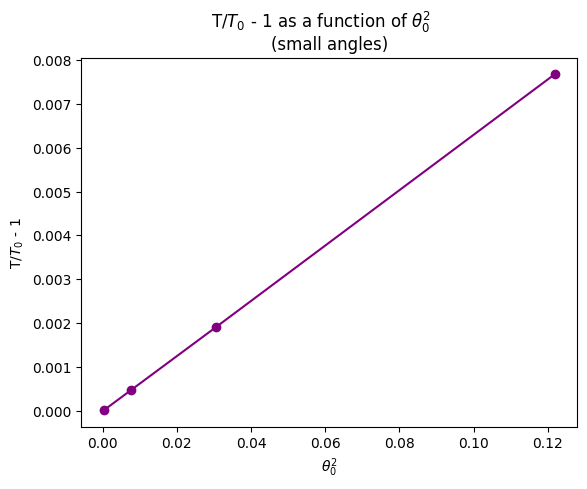

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

#create plot
angles_rad = np.radians(angles)
T_T0 = np.array(T_T0)

plt.plot(np.square(angles_rad[:4]), T_T0[:4] - 1, marker = 'o', color = 'purple')
plt.xlabel(r'$θ_{0}^2$')
plt.ylabel(r'T/$T_{0}$ - 1')
plt.suptitle(r'T/$T_{0}$ - 1 as a function of $θ_{0}^2$')
plt.title('(small angles)')

#calculate slope
slope, intercept = np.polyfit(np.square(angles_rad[:4]), T_T0[:4] - 1, 1)
print('slope = ' + str(slope))
c = Fraction(slope).limit_denominator(20)
print('c = ' + str(c))

#save and download plot as pdf
#plt.savefig("Pendulum_Period.pdf", format = "pdf", bbox_inches = "tight")
#from google.colab import files
#files.download("Pendulum_Period.pdf")

(c)

In [17]:
error = np.abs((T_T0 - 1) - c * np.square(angles_rad))
percent_error = error / (T_T0 - 1) * 100

error_table = []
for angle, error in zip(angles, percent_error):
    error_table.append([angle, error])

headers = ['Angle (degrees)', 'Percent Error']
print(tabulate(error_table, headers = headers, floatfmt = '0.6f'))

  Angle (degrees)    Percent Error
-----------------  ---------------
                1         0.001745
                5         0.043633
               10         0.174564
               20         0.698789
               30         1.574306
               45         3.552870
               70         8.669864
               90        14.488158
